*Exploratory Data Analysis (EDA)*
Goal:
To understand the data in depth before any cleaning or modeling step. We explore:
Dataset overview
Distribution of the target variable sales
Seasonality (day of week, month, year)
Correlation between oil price and sales
Impact of the April 16, 2016 earthquake
Impact of holidays (handling transferred holidays)
Payday effect (15th and end of month)
Analysis by store, cluster and product family
Summary and recommendations for the rest of the series

Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
%matplotlib inline

Loading the data

In [7]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

In [8]:
print(f"train        : {train.shape}")
print(f"test         : {test.shape}")
print(f"oil          : {oil.shape}")
print(f"holidays     : {holidays.shape}")
print(f"stores       : {stores.shape}")
print(f"transactions : {transactions.shape}")

train        : (3000888, 6)
test         : (28512, 5)
oil          : (1218, 2)
holidays     : (350, 6)
stores       : (54, 5)
transactions : (83488, 3)


Overview of the training set

In [19]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1194,1194,2013-01-01,42,CELEBRATION,0.0,0
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0
1192,1192,2013-01-01,42,BOOKS,0.0,0
1191,1191,2013-01-01,42,BEVERAGES,0.0,0


Understanding the columns

In [12]:
train.describe(include="all")

,id,date,store_nbr,family,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,NaN,1684,NaN,33,NaN,NaN
top,NaN,2013-01-01,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,1782,NaN,90936,NaN,NaN
mean,1.500444e+06,NaN,2.750000e+01,NaN,3.577757e+02,2.602770e+00
std,8.662819e+05,NaN,1.558579e+01,NaN,1.101998e+03,1.221888e+01
min,0.000000e+00,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,7.502218e+05,NaN,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,1.500444e+06,NaN,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,2.250665e+06,NaN,4.100000e+01,NaN,1.958473e+02,0.000000e+00


In [13]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [14]:
train.duplicated().sum()

np.int64(0)

In [15]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

Converting the date

In [16]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
transactions["date"] = pd.to_datetime(transactions["date"])

In [17]:
train = train.sort_values("date")

In [18]:
print(f"Date range: {train['date'].min().date()} to {train['date'].max().date()} "
      f"({(train['date'].max() - train['date'].min()).days} days)")
print(f"Number of stores: {train['store_nbr'].nunique()}")
print(f"Number of product families: {train['family'].nunique()}")
print(f"Number of store x family pairs: {train.groupby(['store_nbr', 'family']).ngroups}")
print()
train.info()

Date range: 2013-01-01 to 2017-08-15 (1687 days)
Number of stores: 54
Number of product families: 33
Number of store x family pairs: 1782

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 160.3+ MB


We have 54 stores×33 families=1782 observations per day and 1782×1684=3,000,888 which exactly matches your dataset size.

So the structure is essentially:

Date × Store × Product Family

thus we can eventually do both:
1. Overall sales forecasting
2. Store/product-level sales analysis

*Distribution of the target variable sales*
The metric is RMSLE for sales data, which operates on log(1 + sales). We look at both the raw and transformed distributions.

In [20]:
zero_rate = (train['sales'] == 0).mean()
print(f"Share of rows with sales = 0: {zero_rate:.1%}")
print(train['sales'].describe())

Share of rows with sales = 0: 31.3%
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64


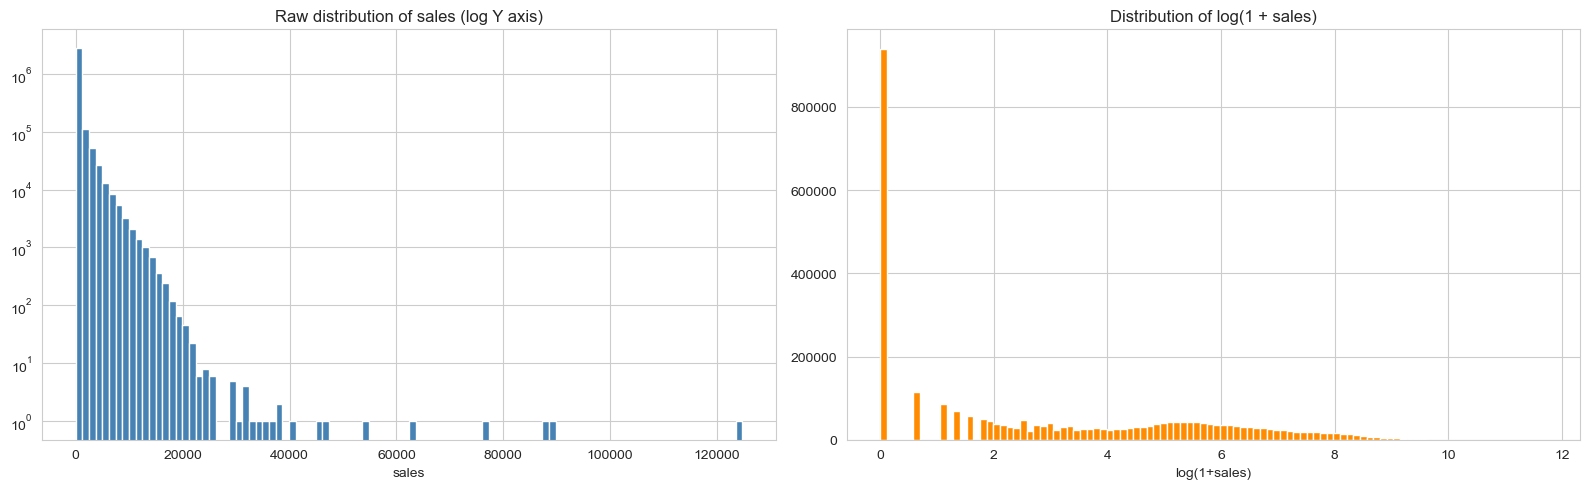

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(train['sales'], bins=100, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title("Raw distribution of sales (log Y axis)")
axes[0].set_xlabel("sales")

axes[1].hist(np.log1p(train['sales']), bins=100, color='darkorange')
axes[1].set_title("Distribution of log(1 + sales)")
axes[1].set_xlabel("log(1+sales)")

plt.tight_layout()
plt.show()

Observation: sales is extremely skewed (many zeros and a long right tail), which fully justifies the choice of RMSLE as the evaluation metric and suggests working on log1p(sales) as the modeling target.

*Seasonality of sales*
We aggregate sales by day (across all stores and families) to observe the overall trend and calendar effects.

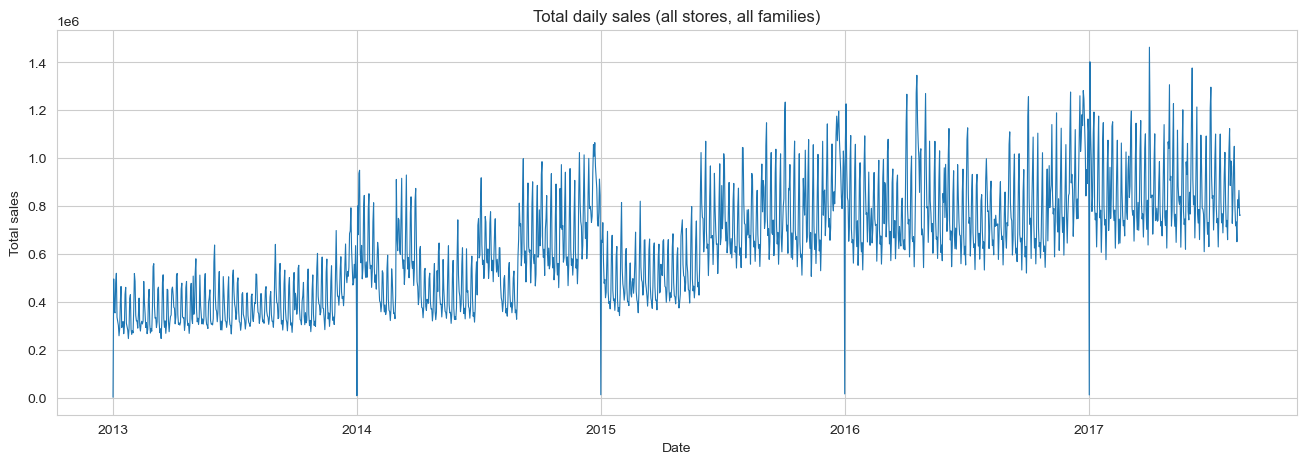

In [22]:
daily = train.groupby('date', as_index=False)['sales'].sum()

plt.figure(figsize=(16, 5))
plt.plot(daily['date'], daily['sales'], linewidth=0.8)
plt.title("Total daily sales (all stores, all families)")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

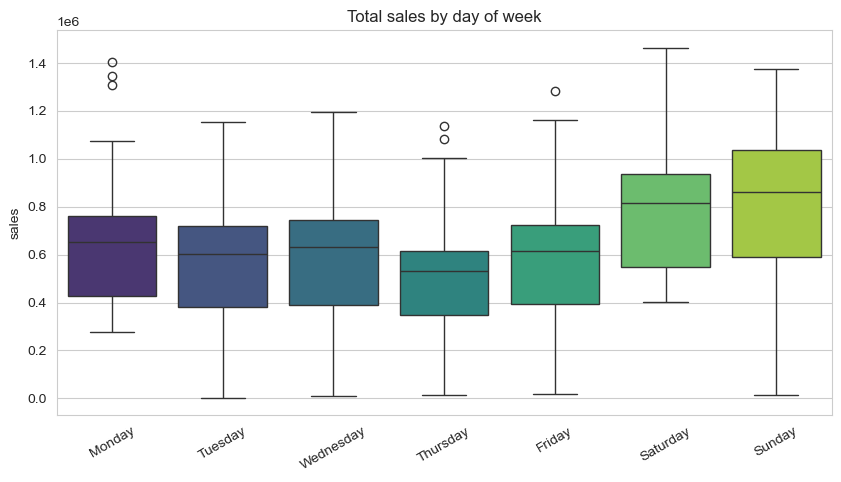

In [23]:
daily['dow'] = daily['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily['dow'] = pd.Categorical(daily['dow'], categories=dow_order, ordered=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=daily, x='dow', y='sales', hue='dow', palette='viridis', legend=False)
plt.title("Total sales by day of week")
plt.xlabel("")
plt.xticks(rotation=30)
plt.show()

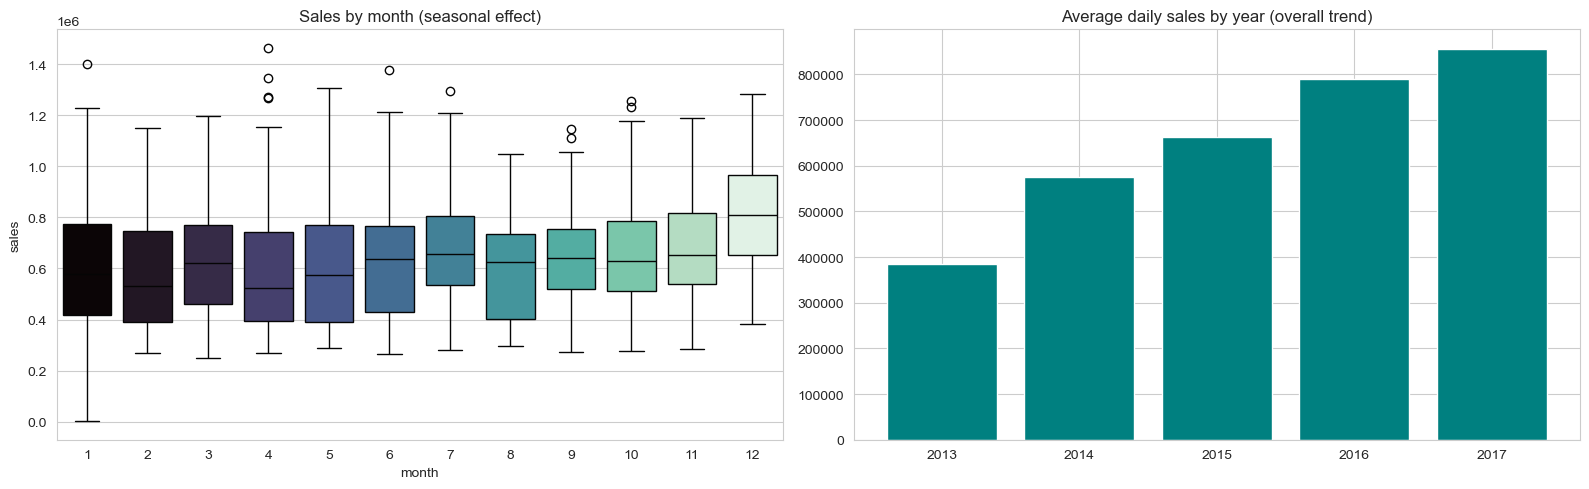

In [24]:
daily['month'] = daily['date'].dt.month
daily['year'] = daily['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=daily, x='month', y='sales', hue='month', palette='mako', legend=False, ax=axes[0])
axes[0].set_title("Sales by month (seasonal effect)")

yearly = daily.groupby('year', as_index=False)['sales'].mean()
axes[1].bar(yearly['year'].astype(str), yearly['sales'], color='teal')
axes[1].set_title("Average daily sales by year (overall trend)")

plt.tight_layout()`
plt.show()

Observation (confirmed on the full dataset): a clear peak around December (year end holidays), an overall upward trend year over year (average daily sales roughly double from 2013 to 2017), and a marked weekend effect (Saturday and Sunday are clearly the strongest days, consistent with Ecuadorian grocery retail patterns).

*Correlation between oil price and sales*
Ecuador's economy is heavily dependent on oil, so we check whether its price (dcoilwtico) is correlated with aggregated sales. Oil prices are only quoted on business days (markets closed on weekends and holidays), so we fill the gaps with forward fill then backward fill for the earliest days.

In [25]:
oil_daily = (
    oil.set_index('date')
    .reindex(pd.date_range(oil['date'].min(), oil['date'].max(), name='date'))
    .reset_index()
)
oil_daily['dcoilwtico'] = oil_daily['dcoilwtico'].ffill().bfill()

print(f"Missing values before filling: {oil['dcoilwtico'].isna().sum()} / {len(oil)}")
print(f"Missing values after ffill/bfill: {oil_daily['dcoilwtico'].isna().sum()} / {len(oil_daily)}")

Missing values before filling: 43 / 1218
Missing values after ffill/bfill: 0 / 1704


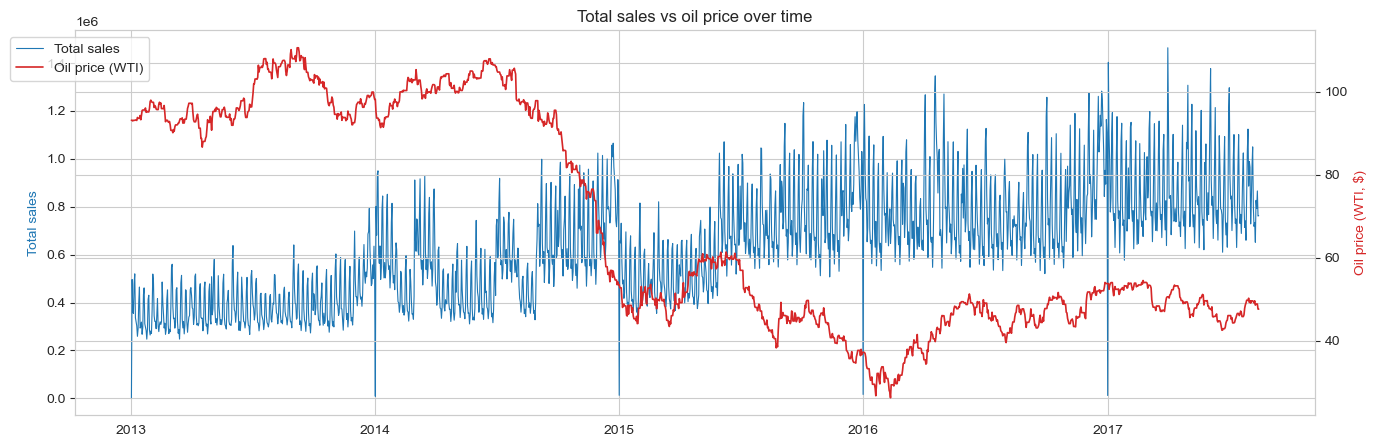

Correlation (Pearson) sales / oil price: -0.627


In [26]:
merged = daily.merge(oil_daily, on='date', how='left')

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(merged['date'], merged['sales'], color='tab:blue', linewidth=0.8, label='Total sales')
ax2.plot(merged['date'], merged['dcoilwtico'], color='tab:red', linewidth=1.2, label='Oil price (WTI)')

ax1.set_ylabel('Total sales', color='tab:blue')
ax2.set_ylabel('Oil price (WTI, $)', color='tab:red')
ax1.set_title("Total sales vs oil price over time")

fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88))
plt.show()

corr = merged[['sales', 'dcoilwtico']].corr().iloc[0, 1]
print(f"Correlation (Pearson) sales / oil price: {corr:.3f}")

Word of caution: the raw correlation between two time series that each have their own trend can be misleading (spurious correlation). A more rigorous analysis should look at first differences or a model that controls for trend, rather than the raw correlation of levels.

*Impact of the April 16, 2016 earthquake*
A magnitude 7.8 earthquake struck Ecuador on April 16, 2016, leading to massive donations of essential goods from supermarkets. We isolate this time window to visualize the shock.

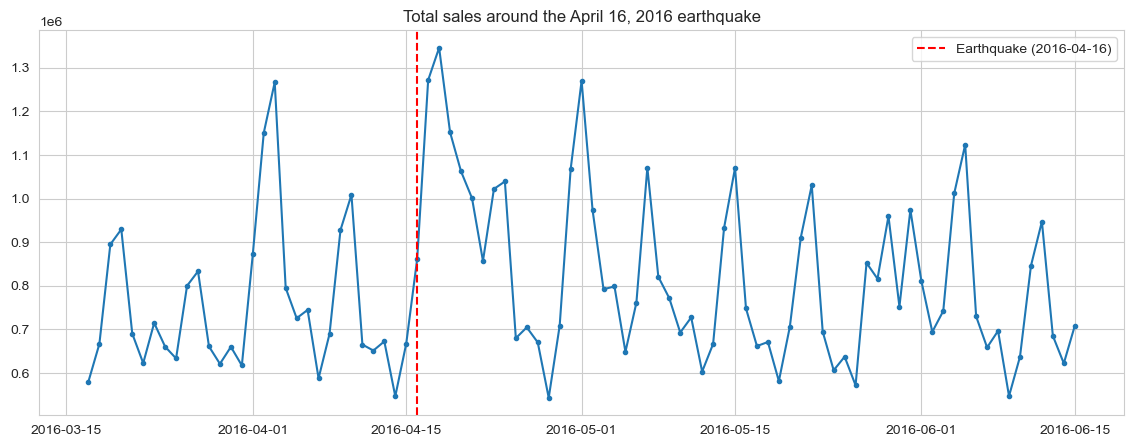

In [27]:
quake_date = pd.Timestamp('2016-04-16')
window = daily[(daily['date'] >= quake_date - pd.Timedelta(days=30)) &
               (daily['date'] <= quake_date + pd.Timedelta(days=60))]

if window.empty:
    print("This period (April to June 2016) is not present in the loaded data.")
else:
    plt.figure(figsize=(14, 5))
    plt.plot(window['date'], window['sales'], marker='o', markersize=3)
    plt.axvline(quake_date, color='red', linestyle='--', label='Earthquake (2016-04-16)')
    plt.title("Total sales around the April 16, 2016 earthquake")
    plt.legend()
    plt.show()

To anticipate for cleaning: this period is an exogenous anomaly, not a recurring seasonal pattern. Two options: (a) create a binary post_earthquake feature for the affected weeks so the model can isolate this shock, or (b) explicitly exclude it from training for models that are sensitive to outliers. This will be decided later depending on the chosen models.

*Impact of holidays:*
A transferred holiday (transferred = True) officially falls on a given date, but is actually a normal working day. The real day off appears as a separate row of type Transfer on the effective date. We rebuild the set of actually non worked dates before comparing sales.

In [28]:
# Officially listed holiday dates that are NOT actually days off (because transferred):
transferred_dates = set(holidays.loc[holidays['transferred'] == True, 'date'])

# Actually non worked dates:
#  - all Holiday / Additional / Bridge / Event rows that were not transferred
#  - plus the Transfer rows (the date the holiday was actually observed)
non_worked_types = ['Holiday', 'Additional', 'Bridge', 'Transfer']
actual_holiday_dates = set(
    holidays.loc[
        holidays['type'].isin(non_worked_types) & (~holidays['date'].isin(transferred_dates)),
        'date'
    ]
    )
# Work Day rows are normally non working days (e.g. a Saturday) reclassified as a working day
# remove them in case they slipped into the set
work_days = set(holidays.loc[holidays['type'] == 'Work Day', 'date'])
actual_holiday_dates -= work_days

print(f"Number of actually non worked dates identified: {len(actual_holiday_dates)}")

Number of actually non worked dates identified: 246


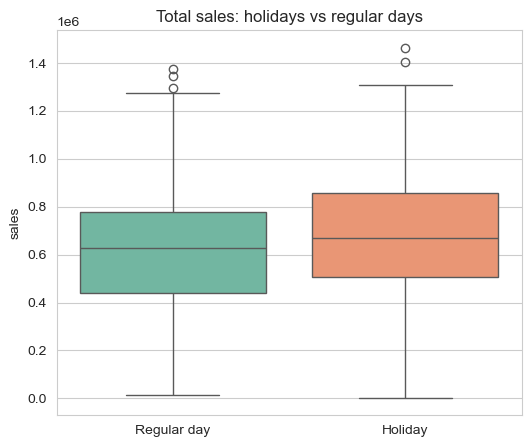

                     mean         median  count
is_holiday                                     
False       631390.387271  629475.643053   1495
True        686329.752559  671145.788057    189


In [29]:
daily['is_holiday'] = daily['date'].isin(actual_holiday_dates)

plt.figure(figsize=(6, 5))
sns.boxplot(data=daily, x='is_holiday', y='sales', hue='is_holiday', palette='Set2', legend=False)
plt.xticks([0, 1], ['Regular day', 'Holiday'])
plt.title("Total sales: holidays vs regular days")
plt.xlabel("")
plt.show()

print(daily.groupby('is_holiday')['sales'].agg(['mean', 'median', 'count']))

*Payday patterns (15th and end of month):*
In Ecuador's public sector, wages are paid on the 15th and on the last day of the month. We test whether these dates show a sales spike.

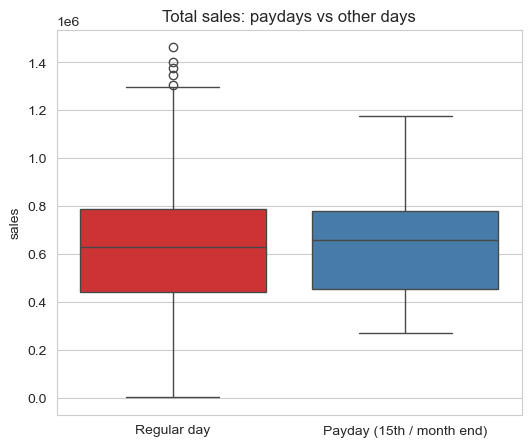

                    mean         median  count
is_payday                                     
False      636962.961167  630811.802872   1573
True       645965.894482  660088.183052    111


In [30]:
daily['day_of_month'] = daily['date'].dt.day
daily['is_month_end'] = daily['date'].dt.is_month_end
daily['is_payday'] = (daily['day_of_month'] == 15) | daily['is_month_end']

plt.figure(figsize=(6, 5))
sns.boxplot(data=daily, x='is_payday', y='sales', hue='is_payday', palette='Set1', legend=False)
plt.xticks([0, 1], ['Regular day', 'Payday (15th / month end)'])
plt.title("Total sales: paydays vs other days")
plt.xlabel("")
plt.show()

print(daily.groupby('is_payday')['sales'].agg(['mean', 'median', 'count']))

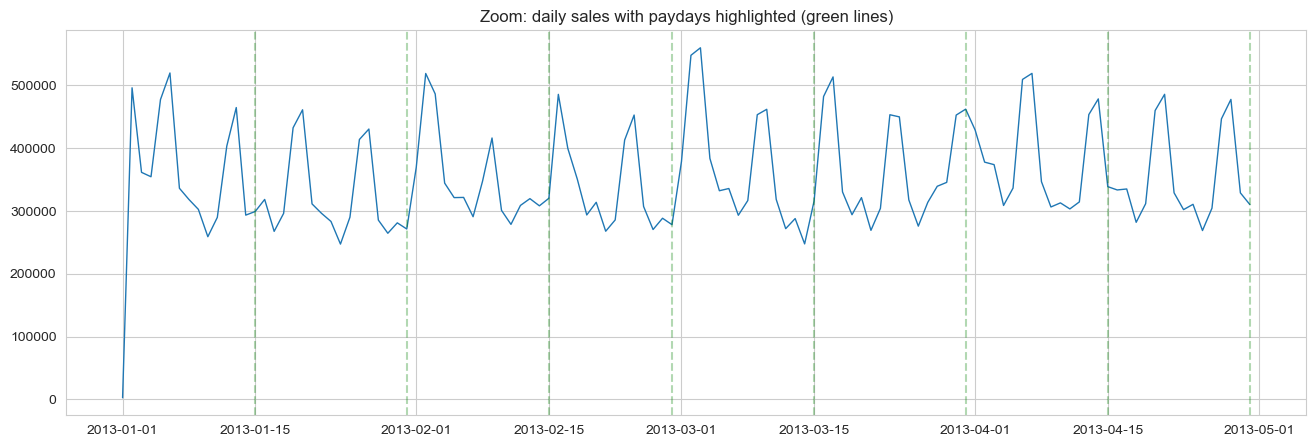

In [31]:
# Zoom on a few months to visualize the spikes around paydays
sample = daily[(daily['date'] >= daily['date'].min()) &
               (daily['date'] < daily['date'].min() + pd.Timedelta(days=120))]

plt.figure(figsize=(16, 5))
plt.plot(sample['date'], sample['sales'], linewidth=1)
for d in sample.loc[sample['is_payday'], 'date']:
    plt.axvline(d, color='green', alpha=0.3, linestyle='--')
plt.title("Zoom: daily sales with paydays highlighted (green lines)")
plt.show()

Feature to create: is_payday (boolean) and/or a distance in days to the next/last payday, which may be more informative than a simple binary flag.

*Analysis by store, cluster and product family*

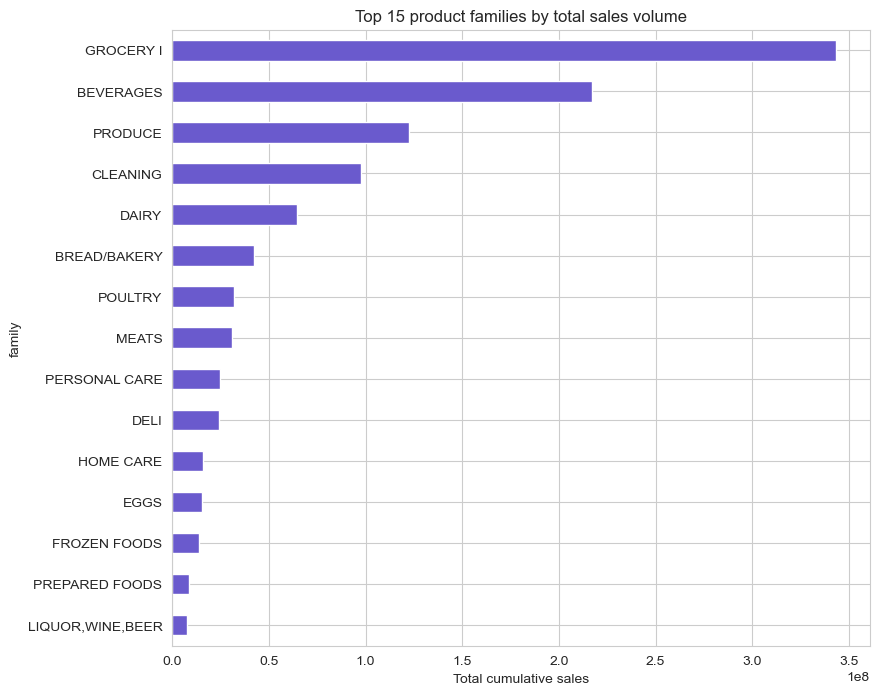

In [32]:
top_families = train.groupby('family')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 8))
top_families.head(15).iloc[::-1].plot(kind='barh', color='slateblue')
plt.title("Top 15 product families by total sales volume")
plt.xlabel("Total cumulative sales")
plt.show()

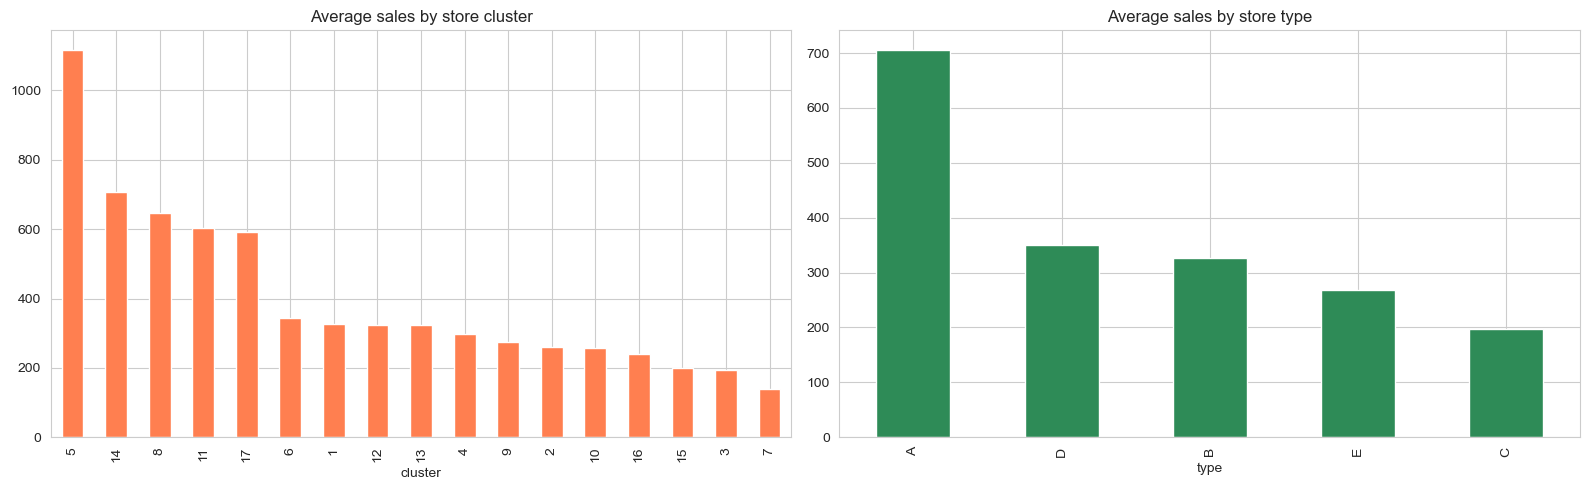

In [33]:
train_stores = train.merge(stores, on='store_nbr', how='left')

cluster_sales = train_stores.groupby('cluster')['sales'].mean().sort_values(ascending=False)
type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cluster_sales.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title("Average sales by store cluster")

type_sales.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("Average sales by store type")

plt.tight_layout()
plt.show()

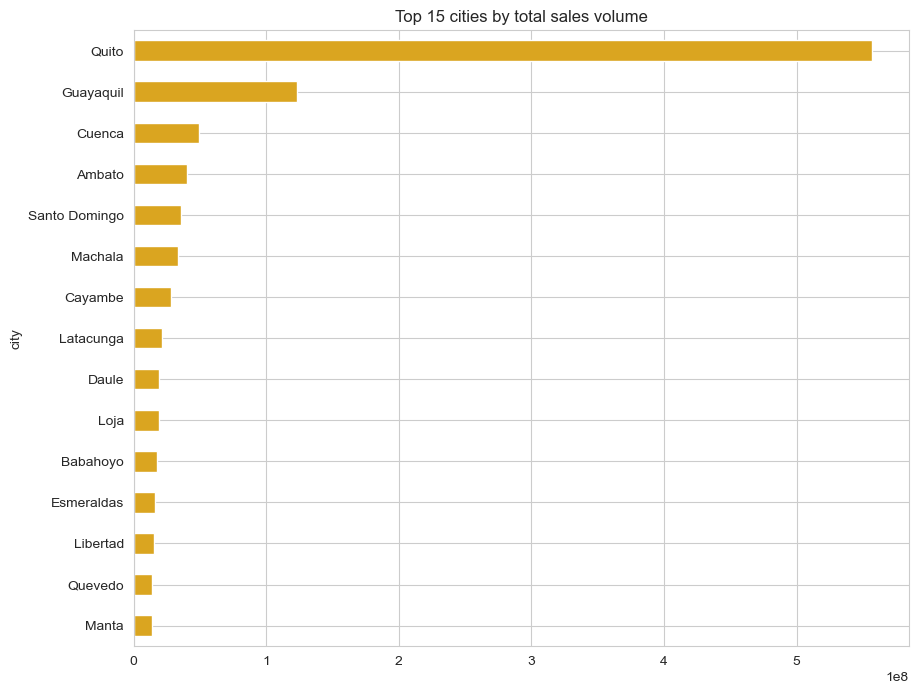

In [34]:
city_sales = train_stores.groupby('city')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
city_sales.head(15).iloc[::-1].plot(kind='barh', color='goldenrod')
plt.title("Top 15 cities by total sales volume")
plt.show()

Observation: strong heterogeneity across stores/clusters/types confirms the value of including store_nbr, cluster, type and city as categorical variables in the models, rather than a single global model ignoring these structural differences.

*Summary and recommendations for the rest of the series*
Takeaways for cleaning
oil.csv has gaps (weekends/holidays with no trading) confirmed here that ffill/bfill works, needs to be productionized.
Transferred holidays must be reprocessed: the officially listed date is not a holiday, it is the associated Transfer row that actually is.
Merge train/test with stores, oil (filled) and the rebuilt holiday calendar.
Takeaways for feature engineering
Target is strongly skewed with many zeros, work on log1p(sales).
Strong seasonal components: day of week, month, year end, calendar features plus lags/rolling means per store family pair.
is_holiday (corrected for transfers) and is_payday (15th/month end) are high potential signals.
The April 16, 2016 earthquake is a one off exogenous anomaly, not a seasonal pattern, needs a dedicated feature or specific handling.
Strong heterogeneity across store/cluster/type/city/family, keep these categorical variables.
Oil/sales correlation should be confirmed on differences rather than raw levels (risk of spurious correlation).

Next step
Cleaning and Preprocessing: build the cleaning and table merging pipeline based on these observations.

In [15]:
daily_sales["sales"].describe()

count    1.684000e+03
mean     6.375564e+05
std      2.344102e+05
min      2.511619e+03
25%      4.427115e+05
50%      6.321889e+05
75%      7.859455e+05
max      1.463084e+06
Name: sales, dtype: float64

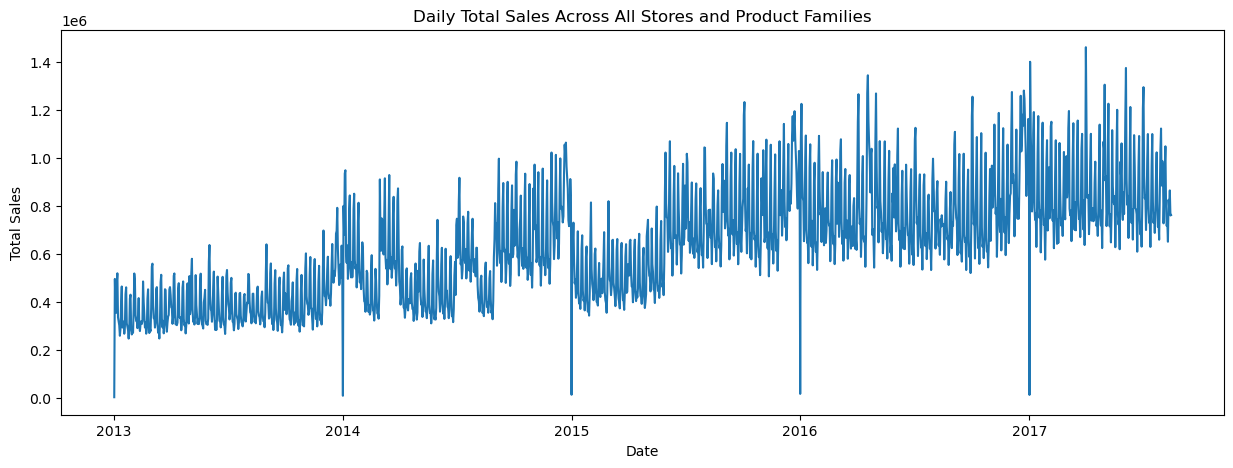

In [16]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales Across All Stores and Product Families")

plt.show()

1. Plot has sharp drops around the beginning of years, these look like dates where sales are zero or extremely low. 
They could represent:
New Year's Day
store closures
holidays
no transactions
special events
We hsve dataset has a holidays_events.csv file, so we can check exactly what's happening.
2. Trend increases and at higher sales levels the spread also appears larger.
   This is evidence in favor of a multiplicative structure, because the magnitude of fluctuations seems to increase with the level. But we shouldn't make the final decision from this plot alone.
We'll verify it using decomposition and/or a log transformation.
But before that let's investigate the time-series structure

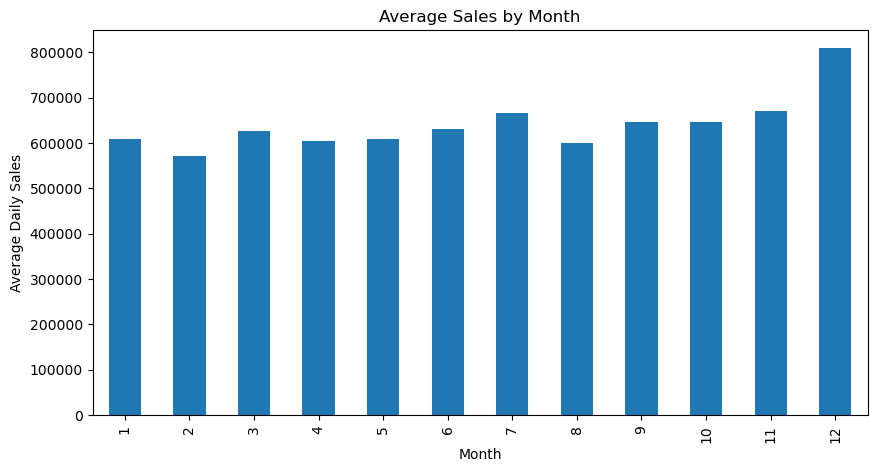

In [17]:
#Monthly pattern
daily_sales["month"] = daily_sales["date"].dt.month

monthly_sales = (
    daily_sales.groupby("month")["sales"]
    .mean()
)

monthly_sales.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.title("Average Sales by Month")

plt.show()

There appears to be some annual/monthly seasonal behavior, especially around December. But we should be careful here.
The monthly plot is averaging across different years, while your series has a strong upward trend. So this plot isn't enough by itself to conclude that December has a purely seasonal effect.

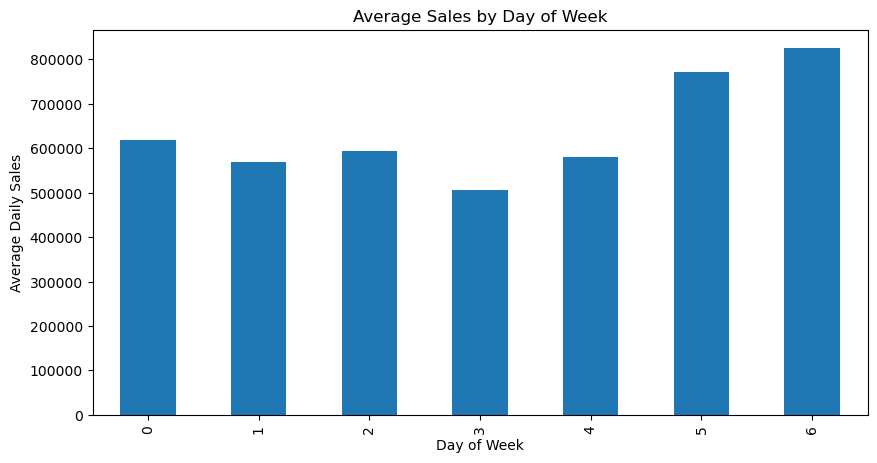

In [18]:
#Day-of-week pattern
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek

weekly_sales = (
    daily_sales.groupby("day_of_week")["sales"]
    .mean()
)

weekly_sales.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Day of Week")
plt.ylabel("Average Daily Sales")
plt.title("Average Sales by Day of Week")

plt.show()

Weekends have substantially higher sales. This gives us strong evidence for weekly seasonality with period s=7

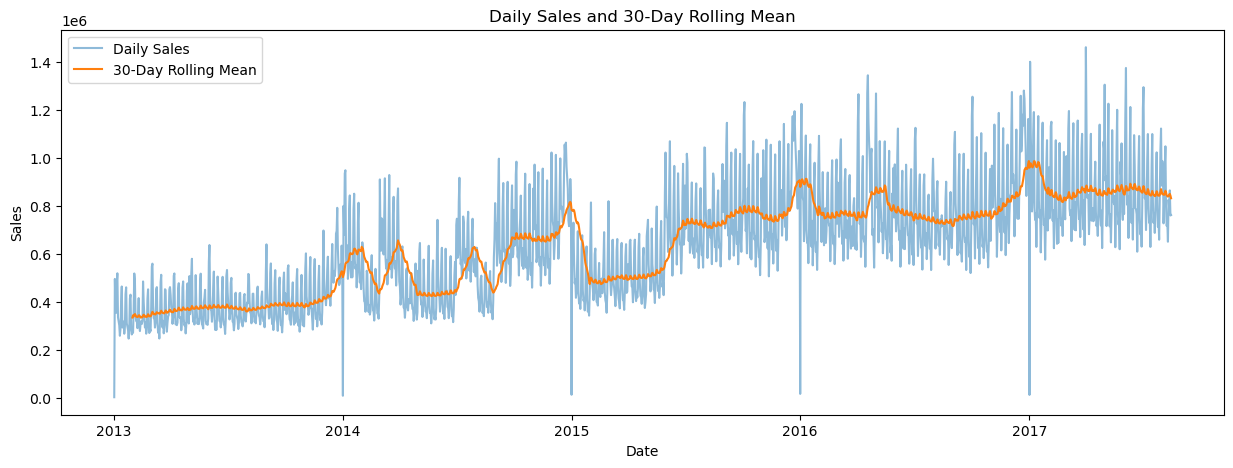

In [19]:
#Rolling mean
daily_sales["rolling_mean_30"] = (
    daily_sales["sales"].rolling(30).mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    alpha=0.5,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_30"],
    label="30-Day Rolling Mean"
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales and 30-Day Rolling Mean")

plt.show()

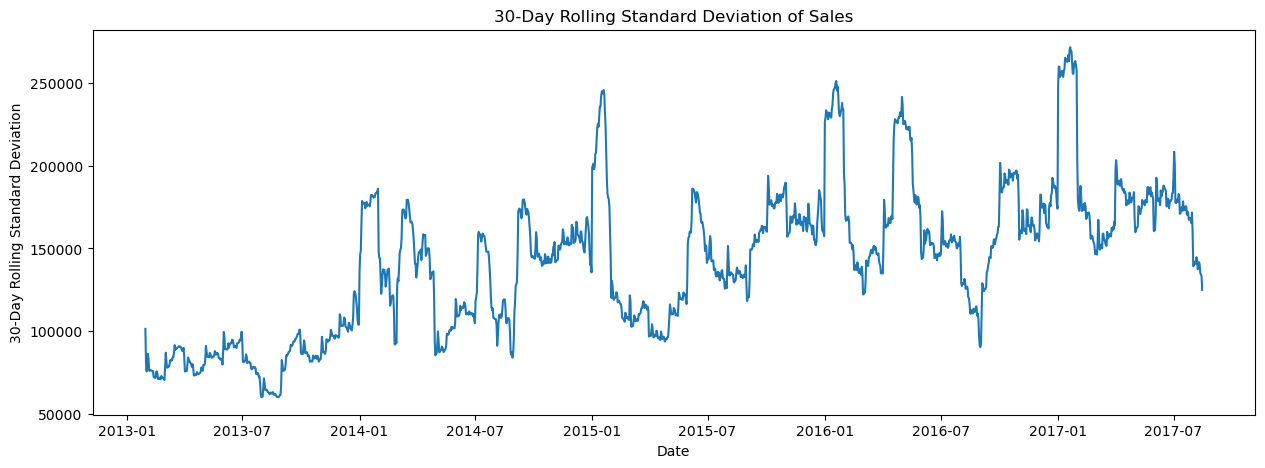

In [20]:
daily_sales["rolling_std_30"] = (
    daily_sales["sales"].rolling(30).std()
)
plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_std_30"]
)

plt.xlabel("Date")
plt.ylabel("30-Day Rolling Standard Deviation")
plt.title("30-Day Rolling Standard Deviation of Sales")

plt.show()

we have higher sales level implies higher variability. This is a strong indication that the variance is not constant.

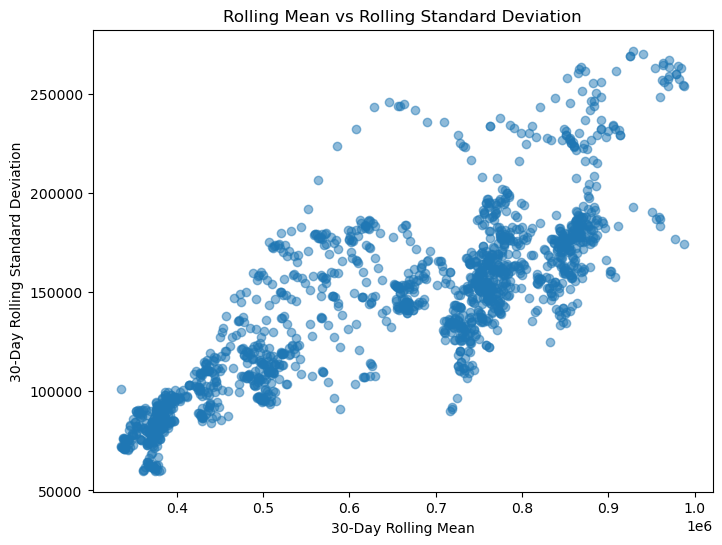

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    daily_sales["rolling_mean_30"],
    daily_sales["rolling_std_30"],
    alpha=0.5
)

plt.xlabel("30-Day Rolling Mean")
plt.ylabel("30-Day Rolling Standard Deviation")
plt.title("Rolling Mean vs Rolling Standard Deviation")

plt.show()

The relationship is clearly positive and Rolling Mean increase implies Rolling SD increase
The increasing relationship between the rolling mean and rolling standard deviation suggests level-dependent variance, making a multiplicative decomposition or logarithmic transformation a reasonable candidate.

In [22]:
daily_sales.loc[
    daily_sales["sales"] < 1000,
    ["date", "sales"]
]


,date,sales
